In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import os
os.chdir('./raw_data/')

In [27]:
# youngest_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='age<65')
# middle_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='age65-80')
# oldest_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='age>80')

age_below_65_df = pd.read_csv('age_below_65.csv')
age_between_65_80_df = pd.read_csv('age_between_65_80.csv')
age_over_80_df = pd.read_csv('age_over_80.csv')

In [53]:
all_df = [age_below_65_df, age_between_65_80_df, age_over_80_df]
for i in range(len(all_df)):
    all_df[i]=all_df[i].rename(columns={"LDL ": "LDL"})

In [54]:
categorical_features = ['sex','tPA(0/1)','EVT(0/1)','HTN(0/1)','DM(0/1)','Dyslipidemia(0/1)','Af(0/1)','smoking(Y/N/Q)']

In [55]:
cont_features = ['age', 'HLOS', 'NIHSS', 'LDL', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c', 'MRS']

In [30]:
label = 'Second_Stroke'

In [31]:
all_df = [age_below_65_df, age_between_65_80_df, age_over_80_df]
map_names = ['Age < 65', 'Age in Between 65 and 80', 'Age > 80']

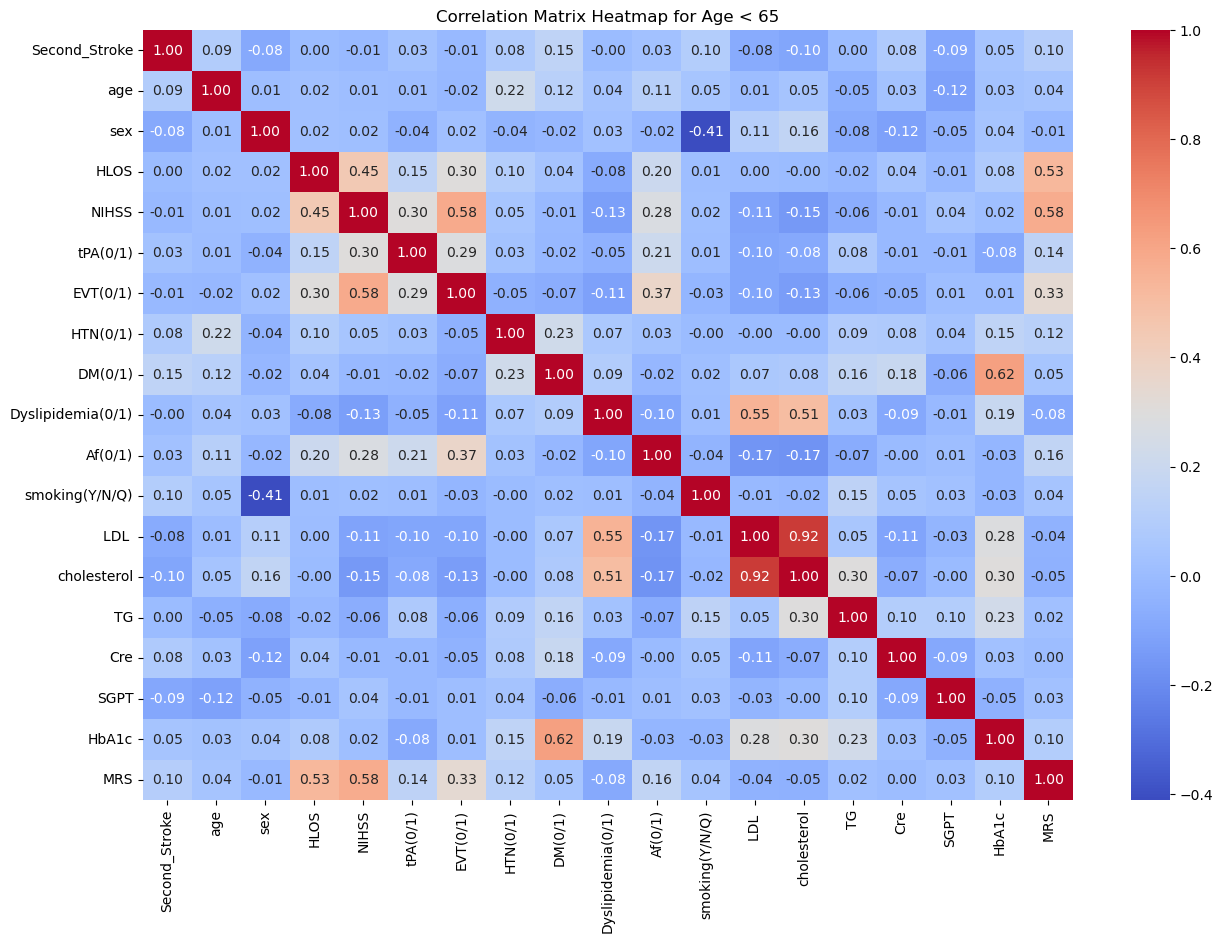

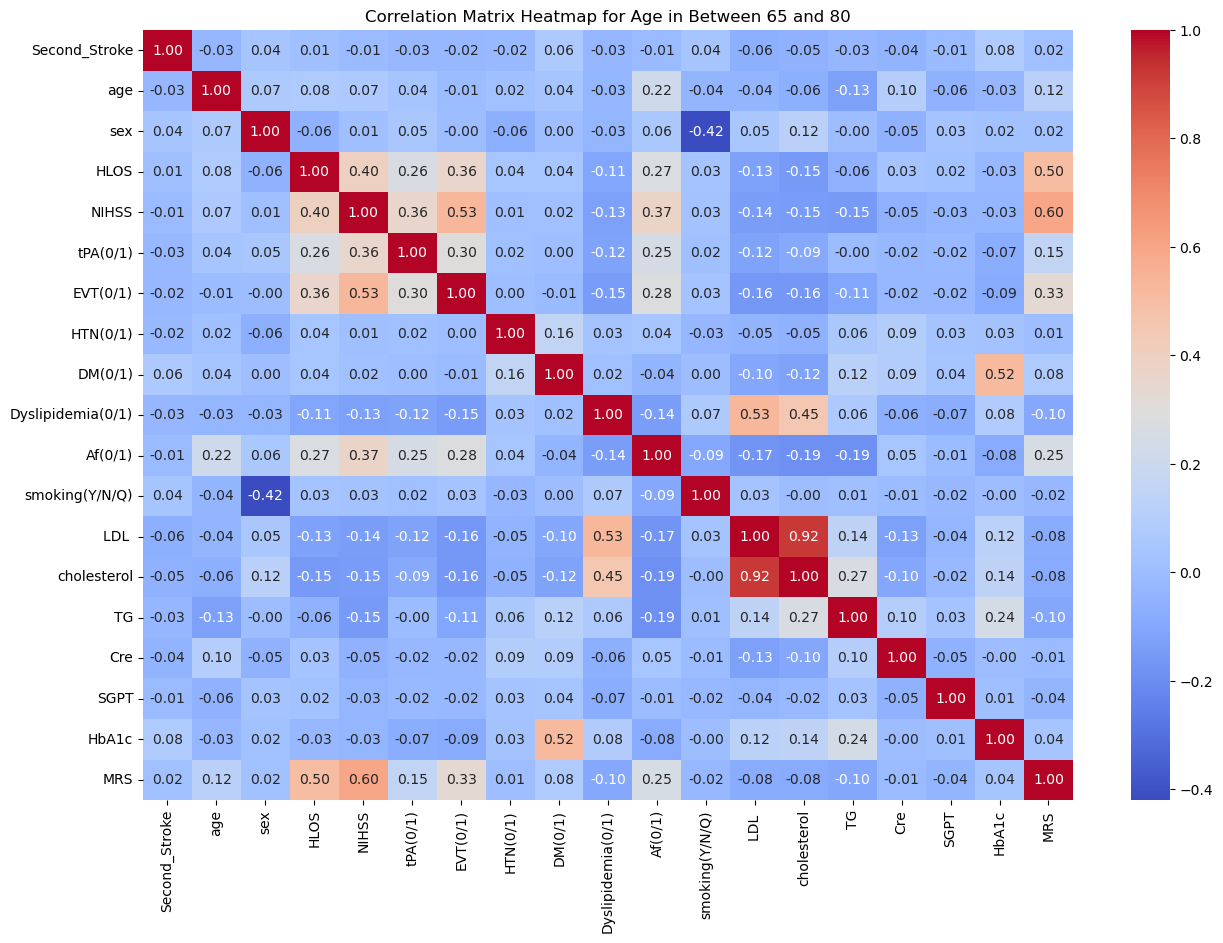

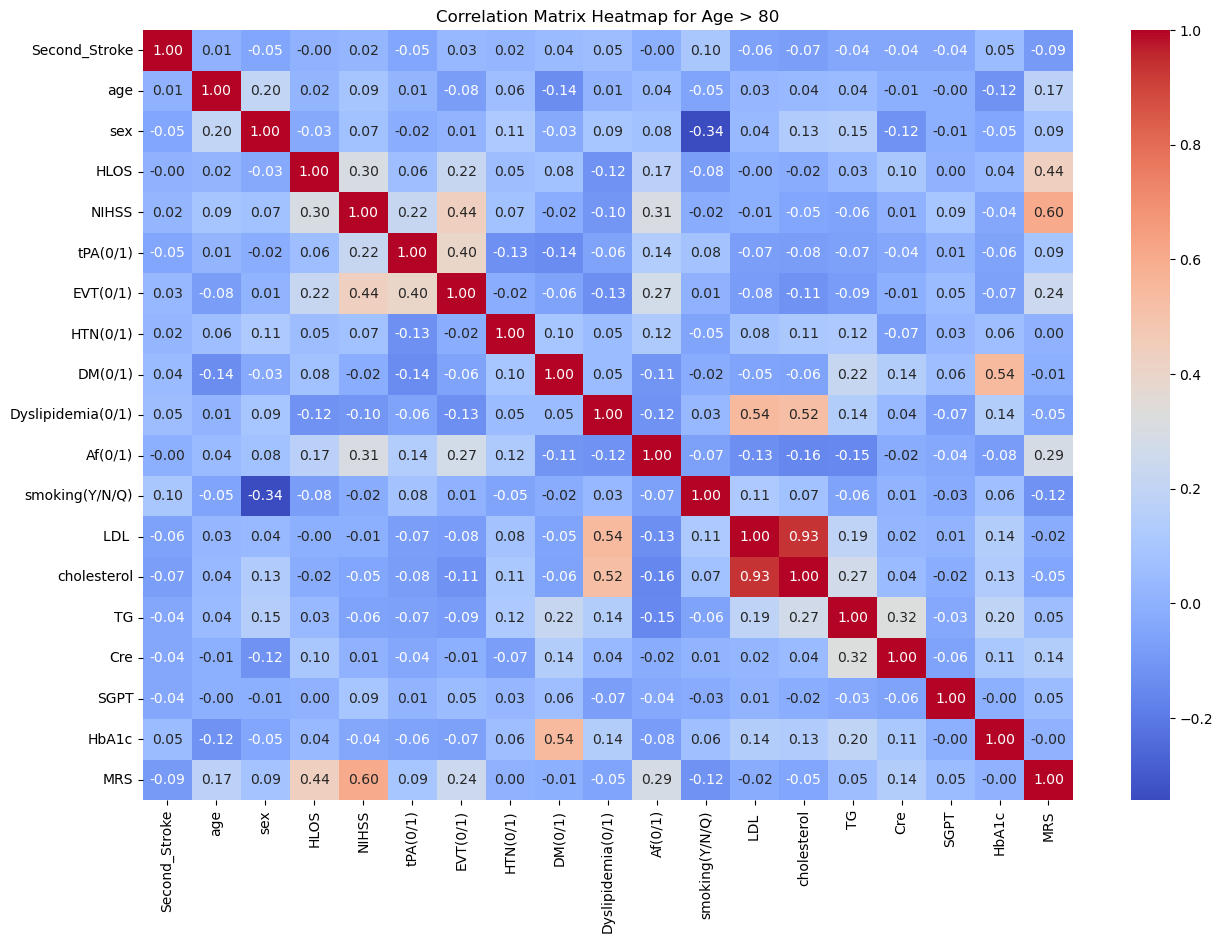

In [32]:
for i in range(len(all_df)):
    
    correlation_matrix = all_df[i].corr()
    
    # Using the correlation_matrix from above
    plt.figure(figsize=(15, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix Heatmap for ' + map_names[i])
    plt.show()

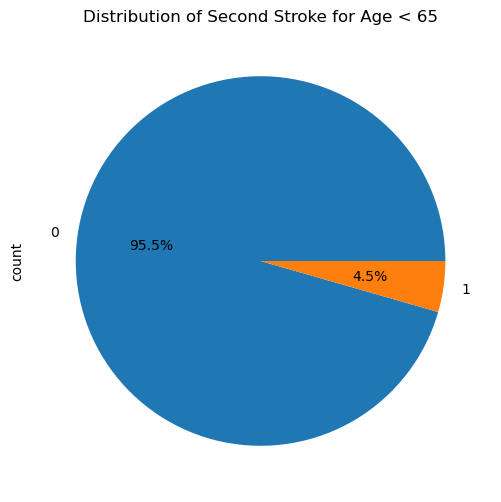

In [40]:
category_counts = age_below_65_df['Second_Stroke'].value_counts()
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Age < 65')

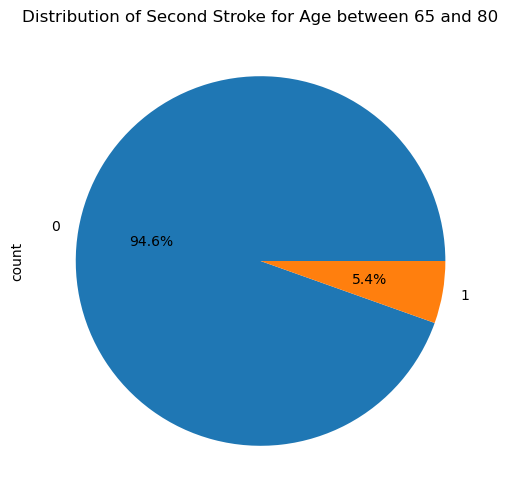

In [41]:
category_counts = age_between_65_80_df['Second_Stroke'].value_counts()
# Plot the pie chart
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Age between 65 and 80')

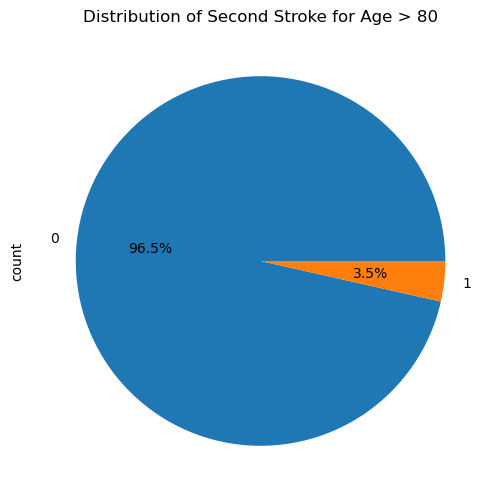

In [43]:
category_counts = age_over_80_df['Second_Stroke'].value_counts()
# Plot the pie chart
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Age > 80')

In [44]:
print(age_below_65_df['Second_Stroke'].value_counts())
print(age_between_65_80_df['Second_Stroke'].value_counts())
print(age_over_80_df['Second_Stroke'].value_counts())

Second_Stroke
0    472
1     22
Name: count, dtype: int64
Second_Stroke
0    695
1     40
Name: count, dtype: int64
Second_Stroke
0    246
1      9
Name: count, dtype: int64


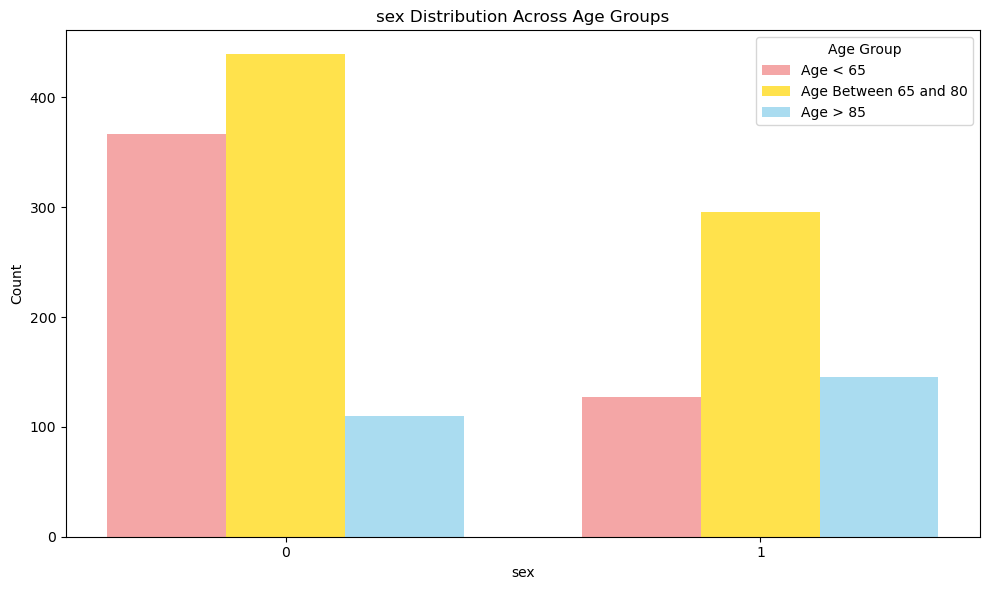

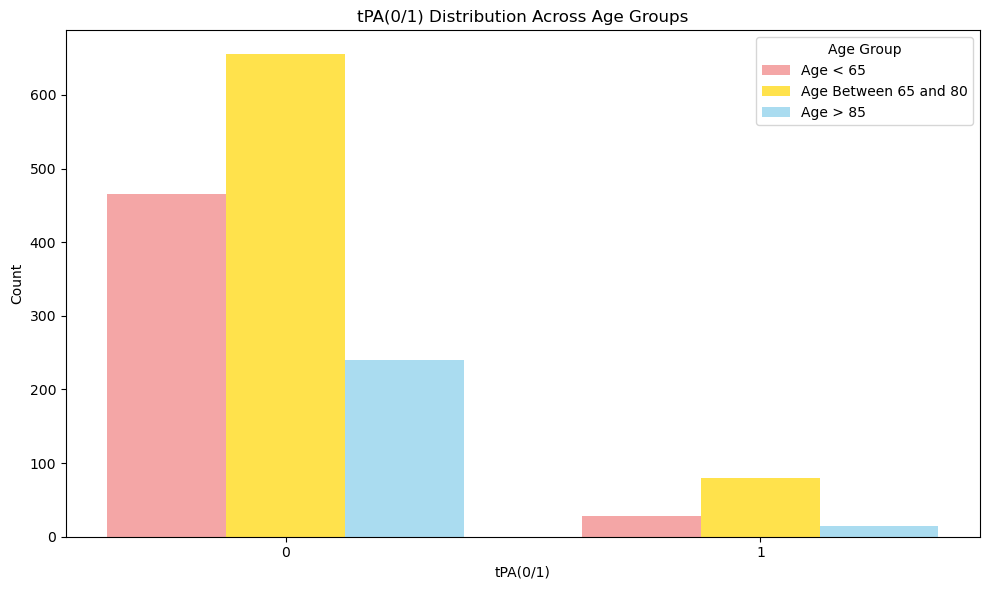

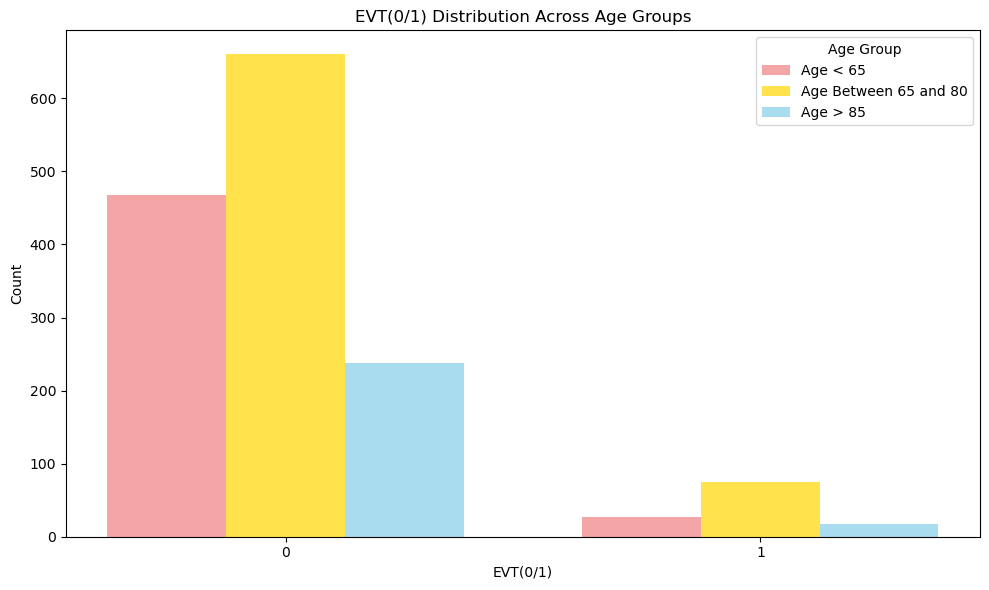

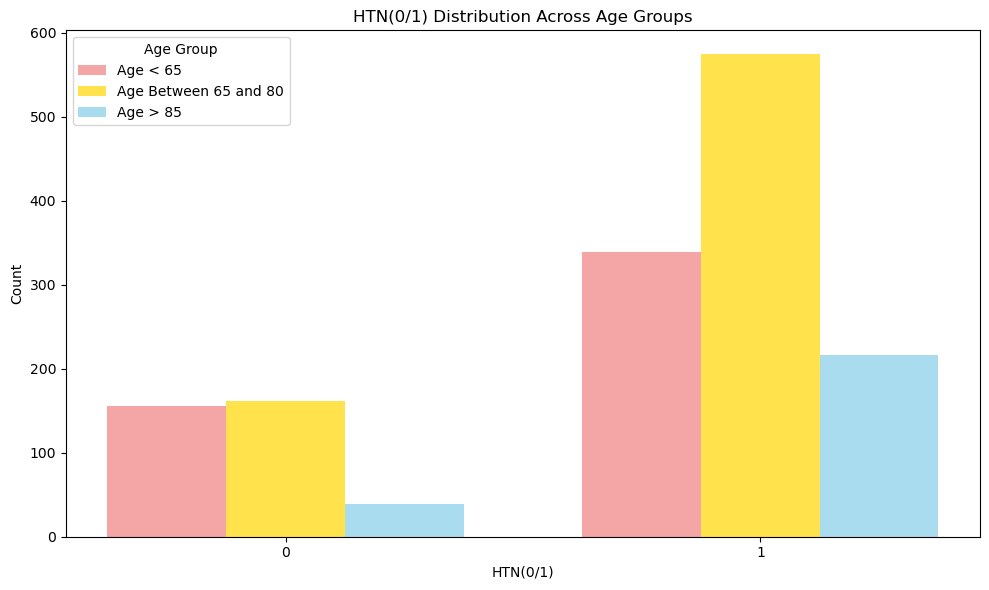

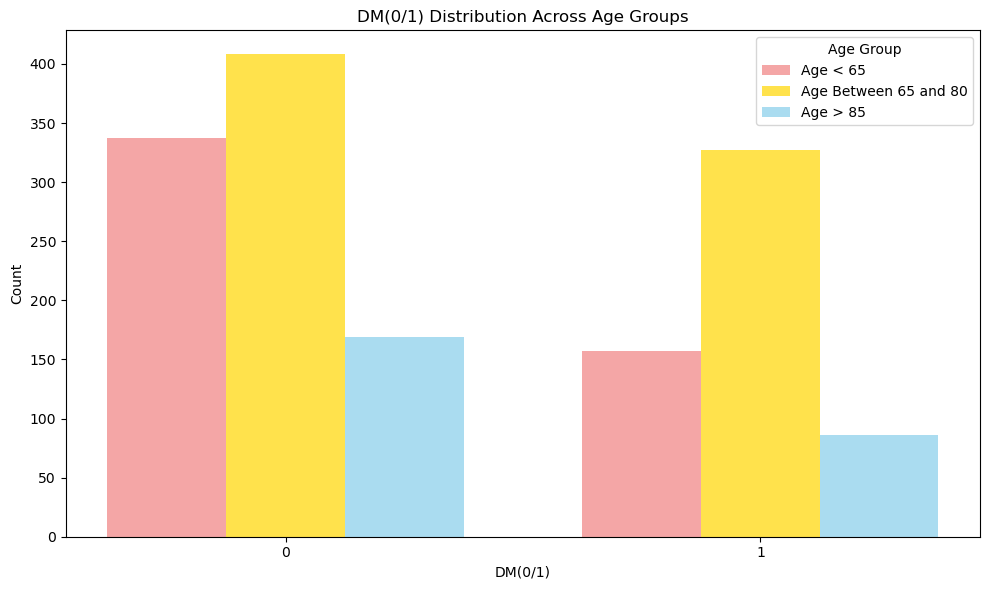

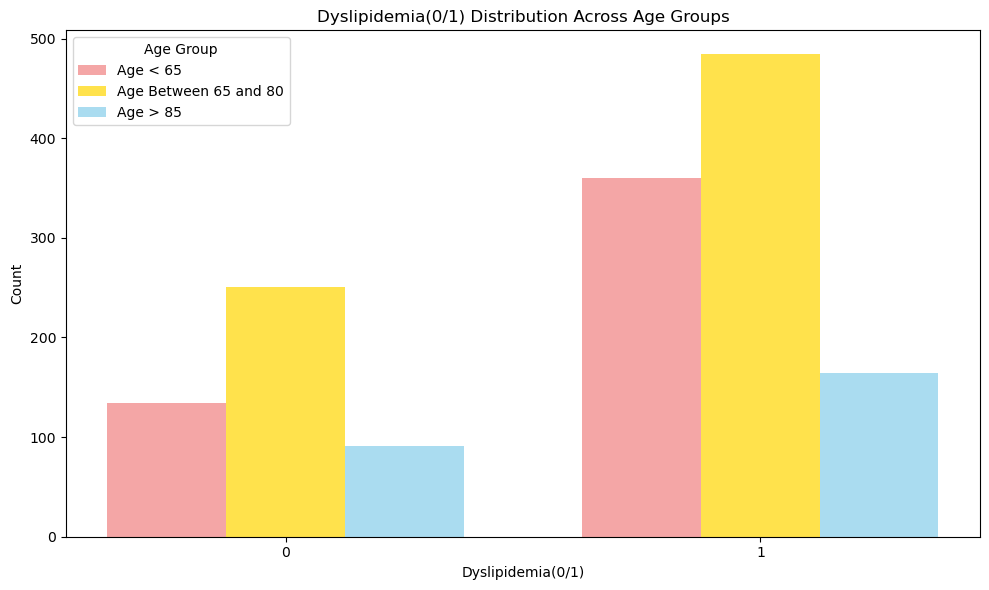

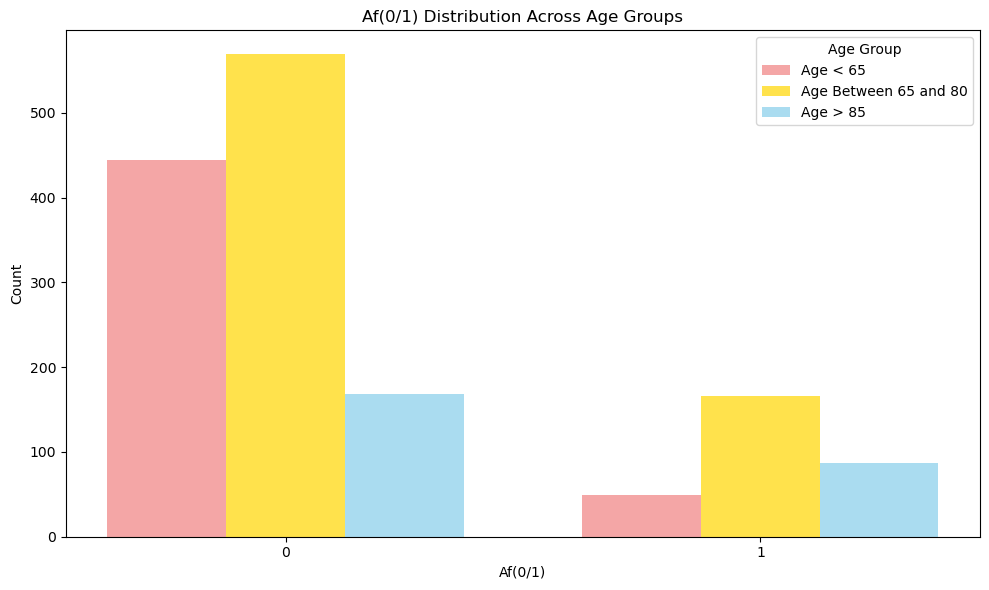

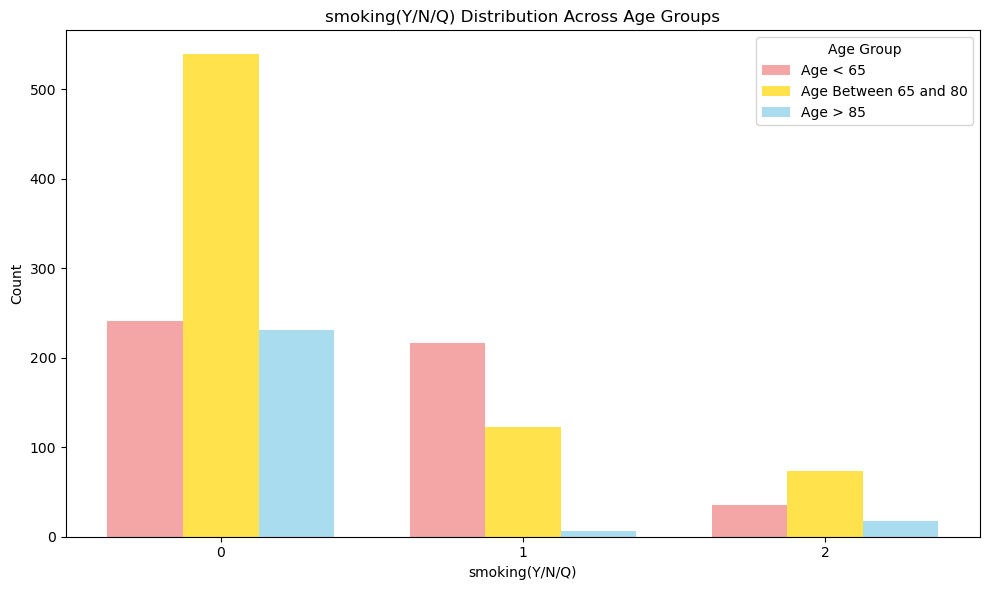

In [36]:
for i in range(len(categorical_features)):
    # Count each category
    young_counts = age_below_65_df[categorical_features[i]].value_counts().sort_index()
    middle_counts = age_between_65_80_df[categorical_features[i]].value_counts().sort_index()
    old_counts = age_over_80_df[categorical_features[i]].value_counts().sort_index()

    # Make sure categories are aligned
    categories = sorted(set(young_counts.index) | set(middle_counts.index) | set(old_counts.index))
    young = [young_counts.get(cat, 0) for cat in categories]
    middle = [middle_counts.get(cat, 0) for cat in categories]
    old = [old_counts.get(cat, 0) for cat in categories]

    # Define bar positions
    x = np.arange(len(categories))
    width = 0.25  # narrower since 3 groups

    # Plot side-by-side
    plt.figure(figsize=(10, 6))
    plt.bar(x - width, young, width=width, color='lightcoral', alpha=0.7, label='Age < 65')
    plt.bar(x, middle, width=width, color='gold', alpha=0.7, label='Age Between 65 and 80')
    plt.bar(x + width, old, width=width, color='skyblue', alpha=0.7, label='Age > 85')
    
    # Formatting
    plt.xticks(x, categories)
    plt.xlabel(categorical_features[i])
    plt.ylabel('Count')
    plt.title(categorical_features[i] + ' Distribution Across Age Groups')
    plt.legend(title='Age Group')
    plt.tight_layout()
    plt.show()

In [56]:
age_below_65_df['age_group'] = 'young'
age_between_65_80_df['age_group'] = 'middle'
age_over_80_df['age_group'] = 'old'
df_combined = pd.concat([age_below_65_df, age_between_65_80_df, age_over_80_df])

In [58]:
df_combined = df_combined.rename(columns={"LDL ": "LDL"})

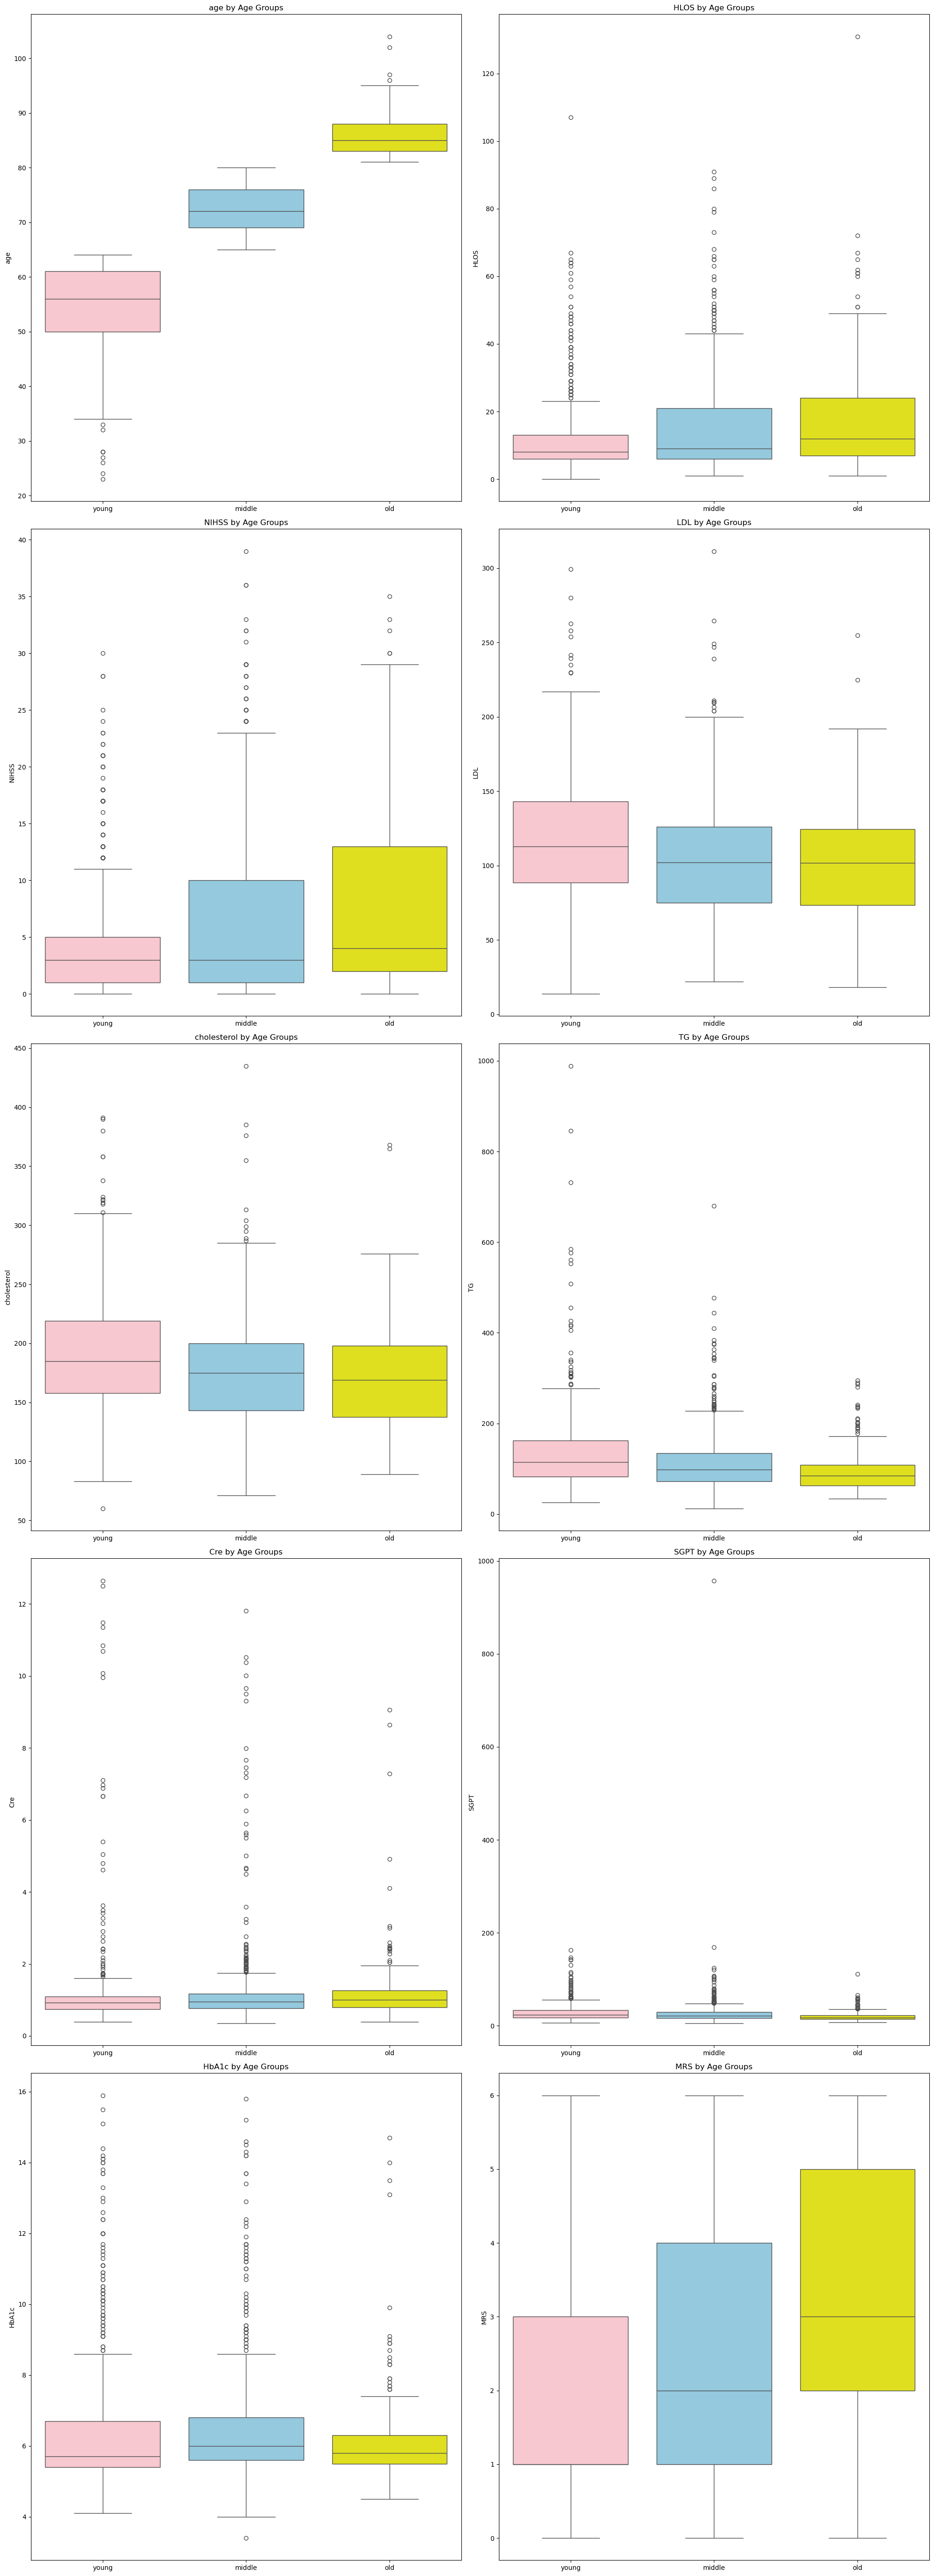

In [61]:
features = cont_features
fig, axes = plt.subplots(5, 2, figsize=(20, 55))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df_combined, x='age_group', y=feature, hue='age_group', palette=['pink', 'skyblue', 'yellow'], ax=ax)
    ax.set_title(f'{feature} by Age Groups')
    ax.set_xlabel('')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()